In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import numpy as np
from pathlib import Path 

dir = "benchmark_results/"
path = Path(dir)
dfs = []
nbeaps = set(["1-nbeap", "2-nbeap", "3-nbeap", "4-nbeap", "5-nbeap", 
              "6-nbeap", "7-nbeap", "8-nbeap", "9-nbeap", "10-nbeap",
              "beap"])


for p in path.iterdir():
    pattern = r".*/bench_(.*).csv"
    name = re.search(pattern, str(p)).group(1)
    df = pd.read_csv(p)
    df["size"] =  df["name"].str.split("/").str[1].astype("float64")
    df["op"] = df["name"].str.extract(r"BM_([^/<]+)")
    df["stat"] = df["name"].str.extract(r".*:\d+_(.*)")
    df = df[df["stat"].notna()]

    dfs.append((df, name))


In [7]:
# DS = [ ds for (_, ds) in dfs]
DS = sorted([ds for _, ds in dfs])
colors = [plt.get_cmap("tab20")(i) for i in np.linspace(0, 1, len(DS))]
color_map = dict(zip(DS, colors))

Start with comparing all nbeaps

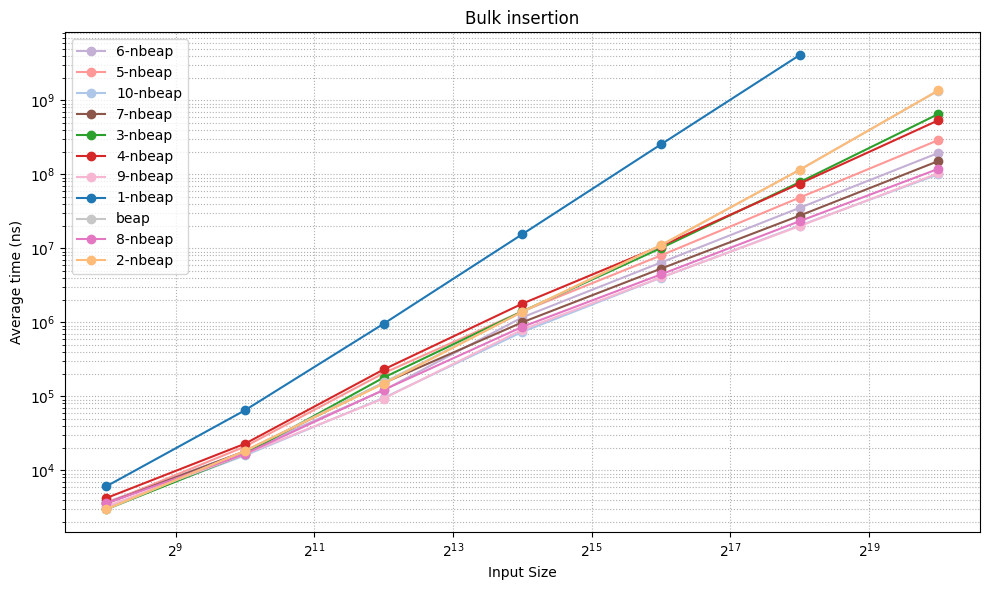

In [43]:
# Construct
plt.figure(figsize=(10, 6))
plt.title(f"Bulk insertion")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "Construct"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

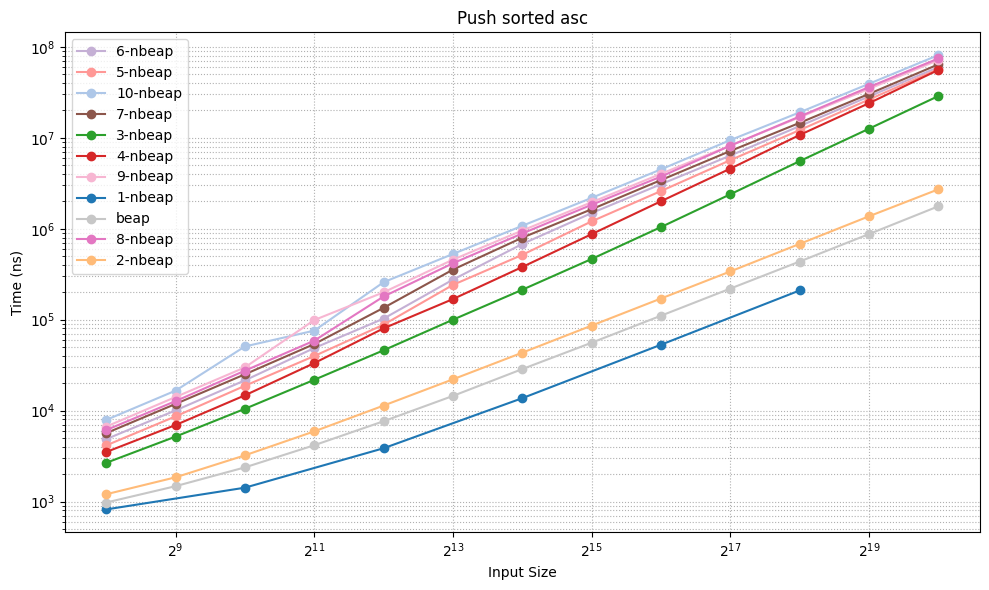

In [45]:
# push sorted asc
plt.figure(figsize=(10, 6))
plt.title(f"Push sorted asc")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "PushSortedAsc"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

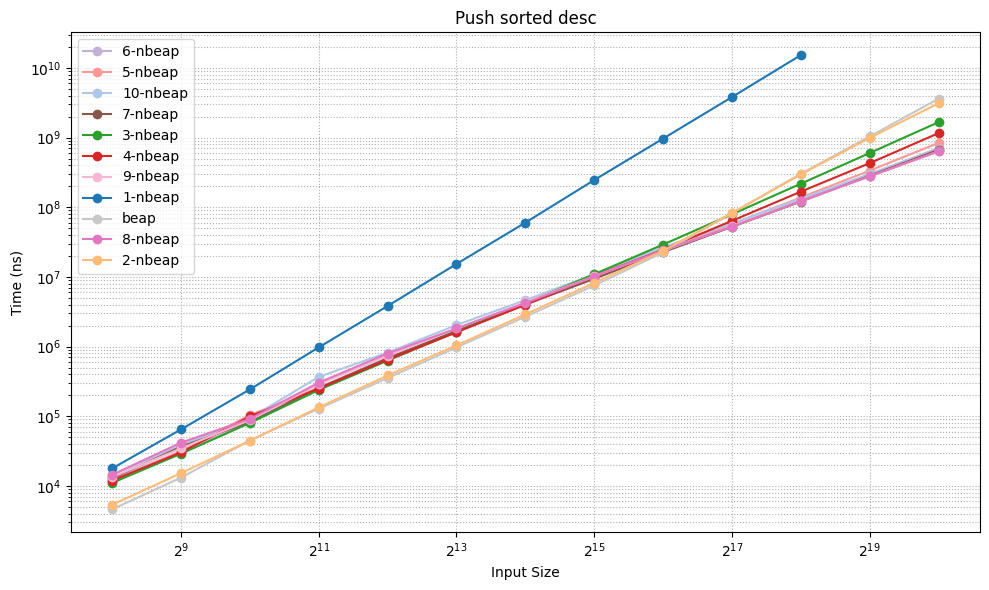

In [46]:
# insertion push sorted desc
plt.figure(figsize=(10, 6))
plt.title(f"Push sorted desc")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "PushSortedDesc"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

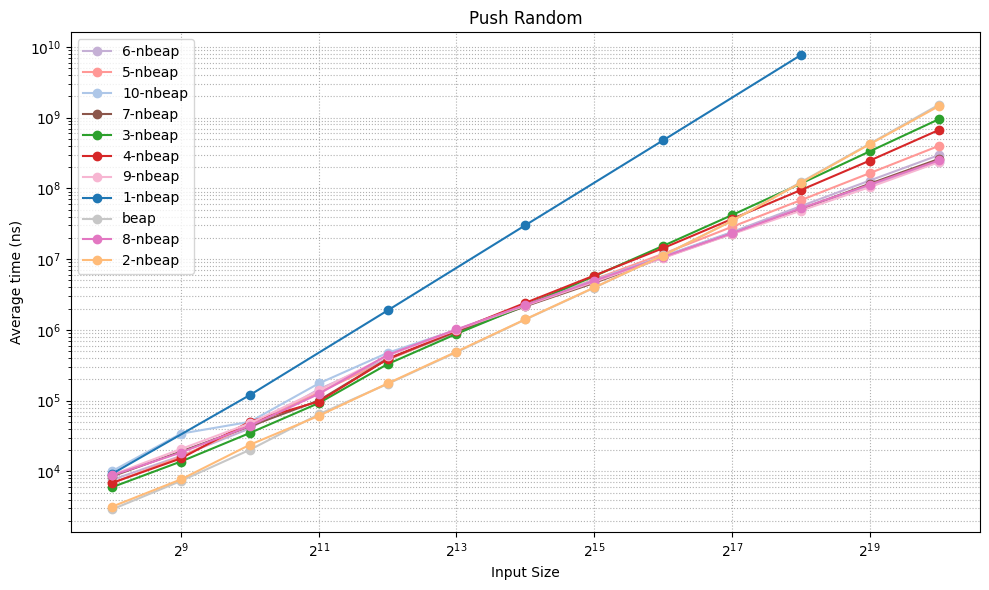

In [38]:
# insertion push random 
plt.figure(figsize=(10, 6))
plt.title(f"Push Random")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "PushRandom"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

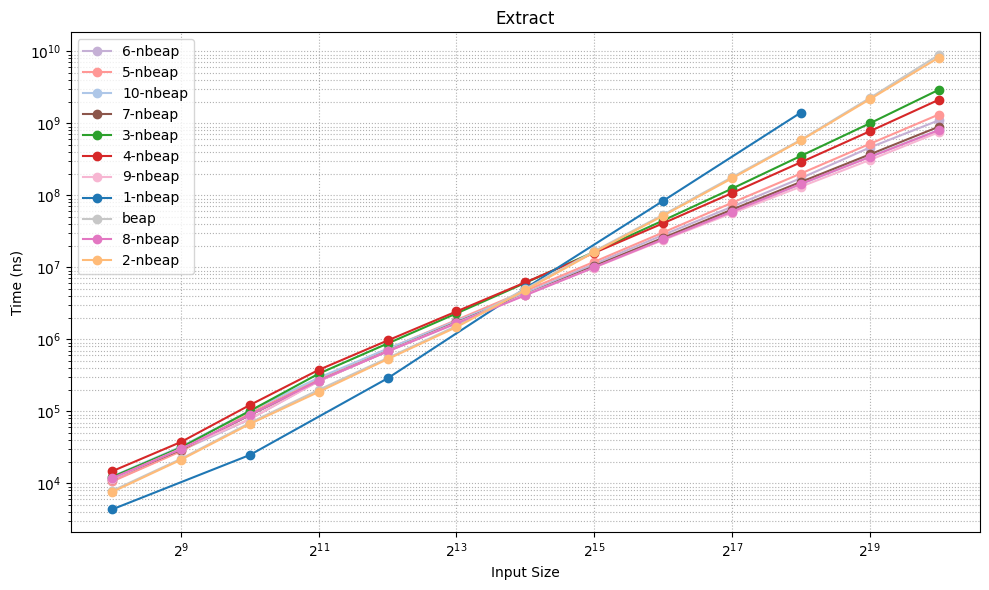

In [47]:
# extract
plt.figure(figsize=(10, 6))
plt.title(f"Extract")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "Extract"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

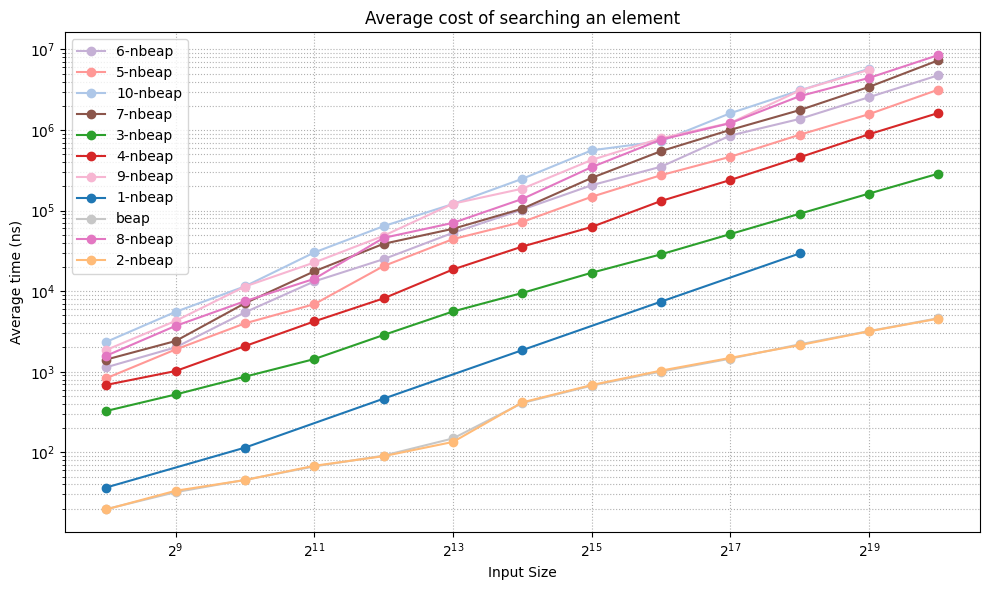

In [49]:
# search
plt.figure(figsize=(10, 6))
plt.title(f"Average cost of searching an element")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "Search"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op["cpu_time"] = df_op["cpu_time"] / (0.05 * df_op['size'])
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

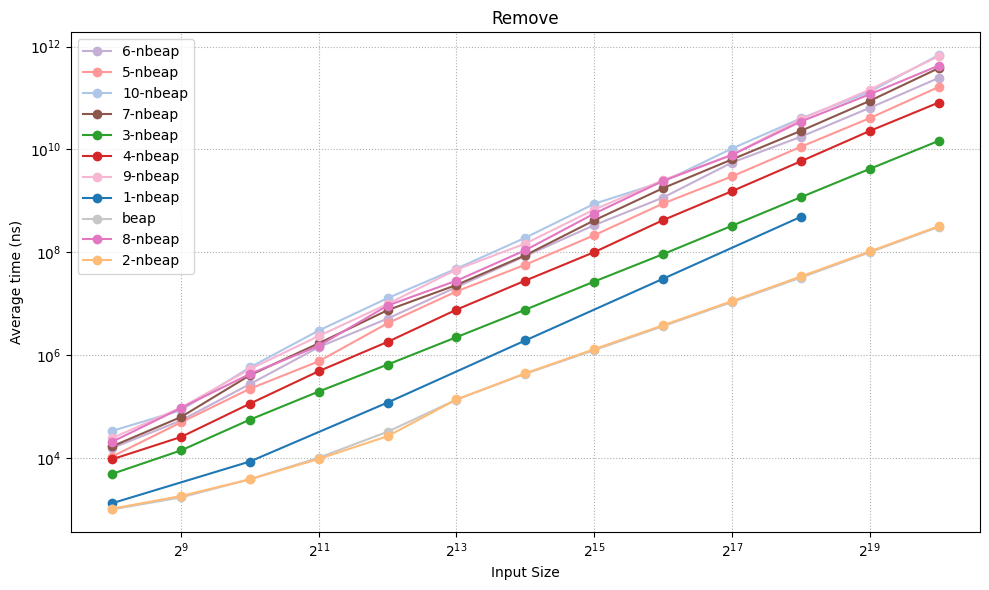

In [50]:
# Remove
plt.figure(figsize=(10, 6))
plt.title(f"Remove")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    if ds not in nbeaps:
        continue
    df_op = df[df["op"] == "Remove"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

the rest 

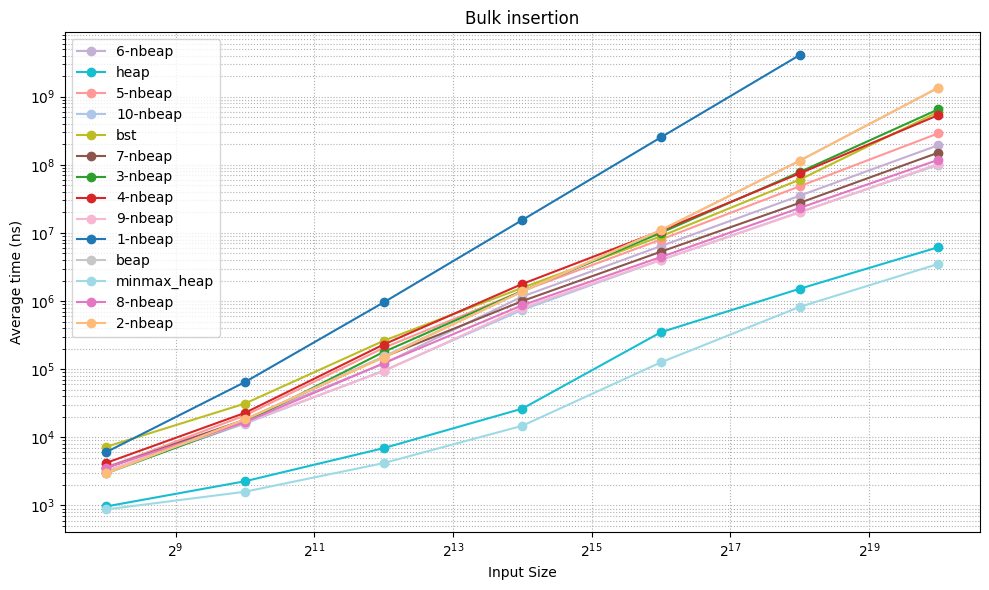

In [42]:
# Construct
plt.figure(figsize=(10, 6))
plt.title(f"Bulk insertion")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "Construct"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

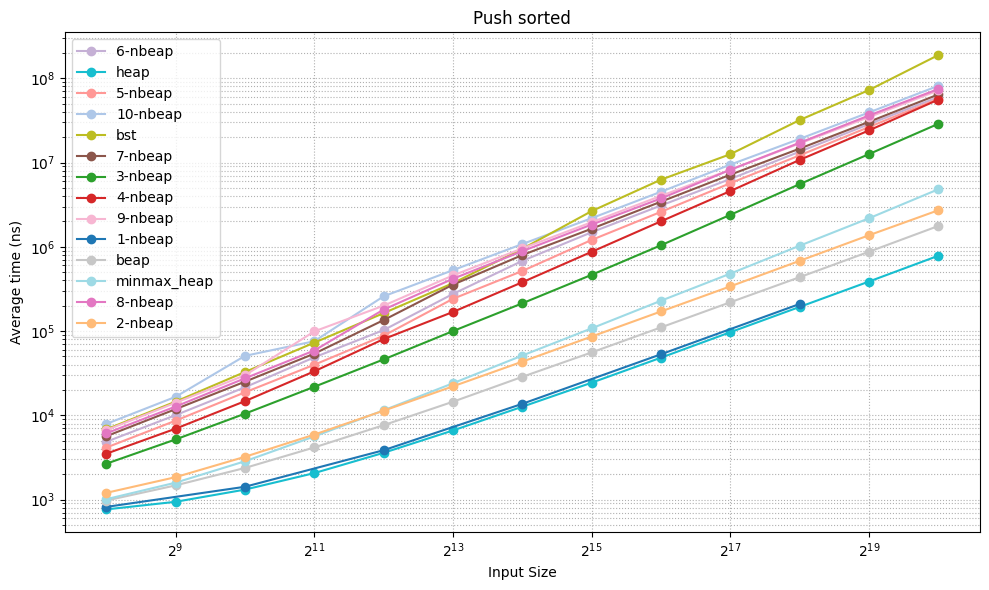

In [22]:
# Insertion - push sorted
plt.figure(figsize=(10, 6))
plt.title(f"Push sorted")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "PushSortedAsc"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

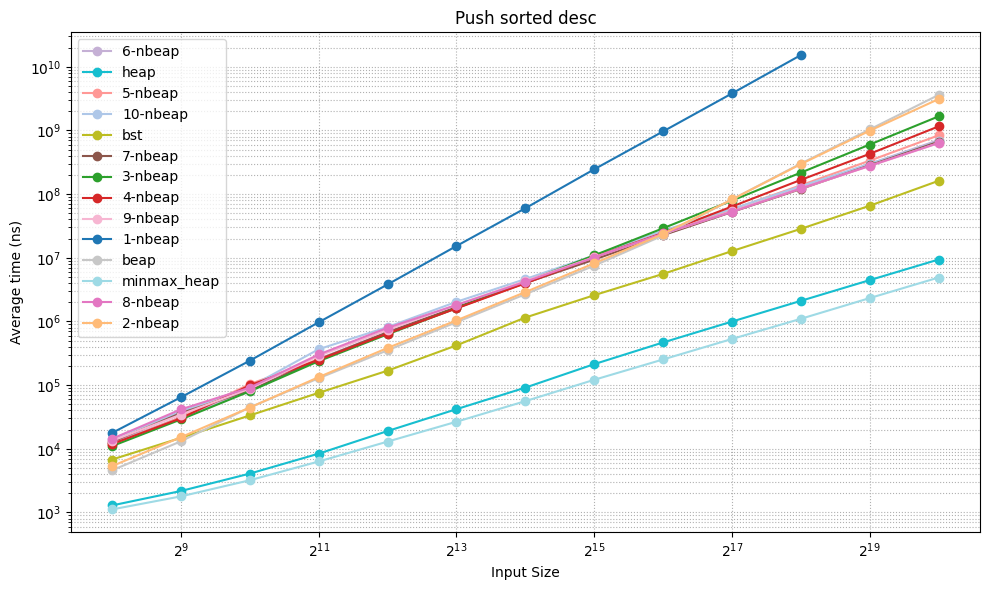

In [25]:
# Insertion - push sorted desc
plt.figure(figsize=(10, 6))
plt.title(f"Push sorted desc")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "PushSortedDesc"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

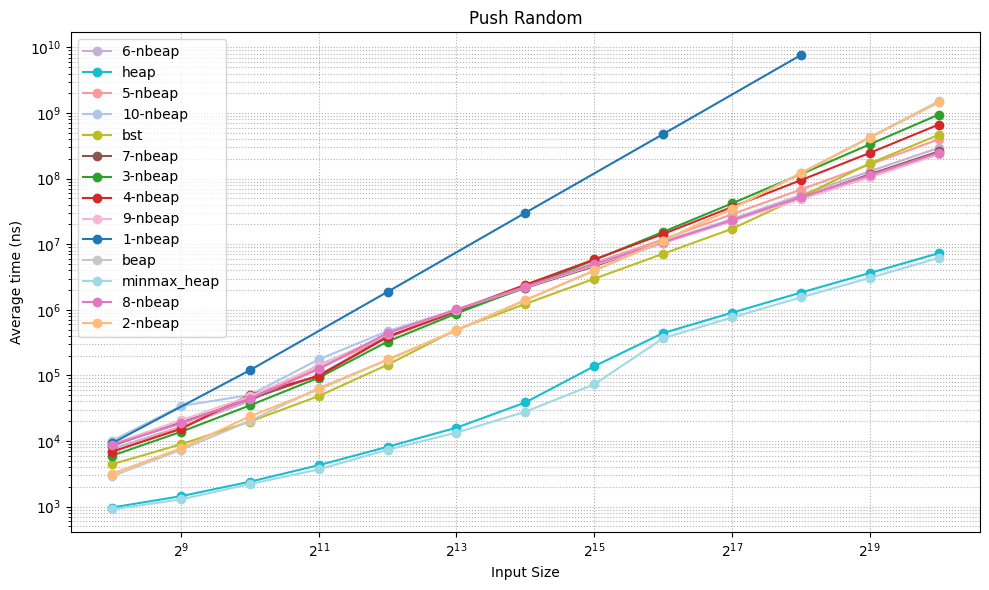

In [27]:
# Insertion - push ramdom
plt.figure(figsize=(10, 6))
plt.title(f"Push Random")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "PushRandom"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

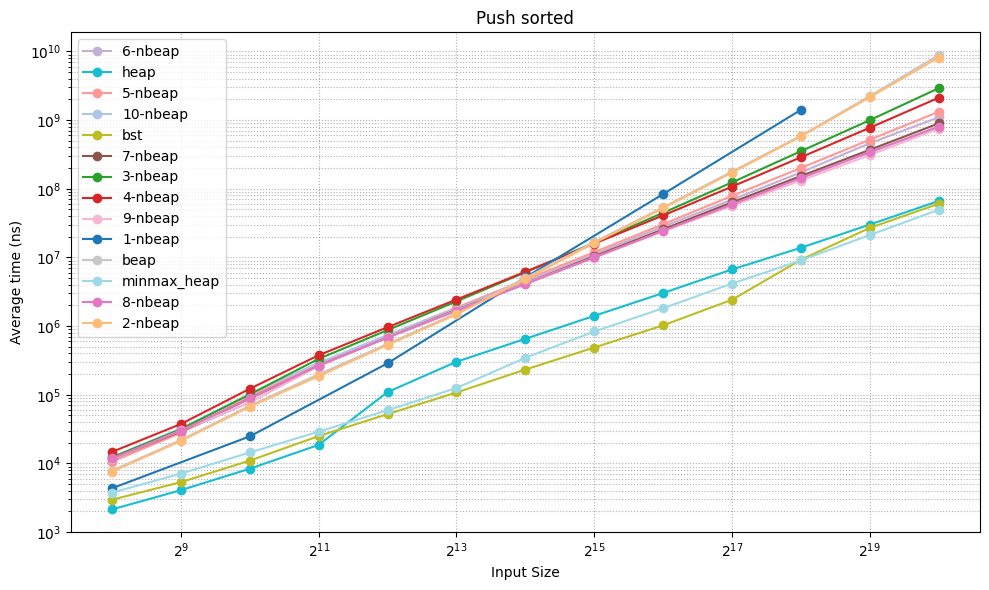

In [ ]:
# Extract
plt.figure(figsize=(10, 6))
plt.title(f"Extract")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "Extract"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

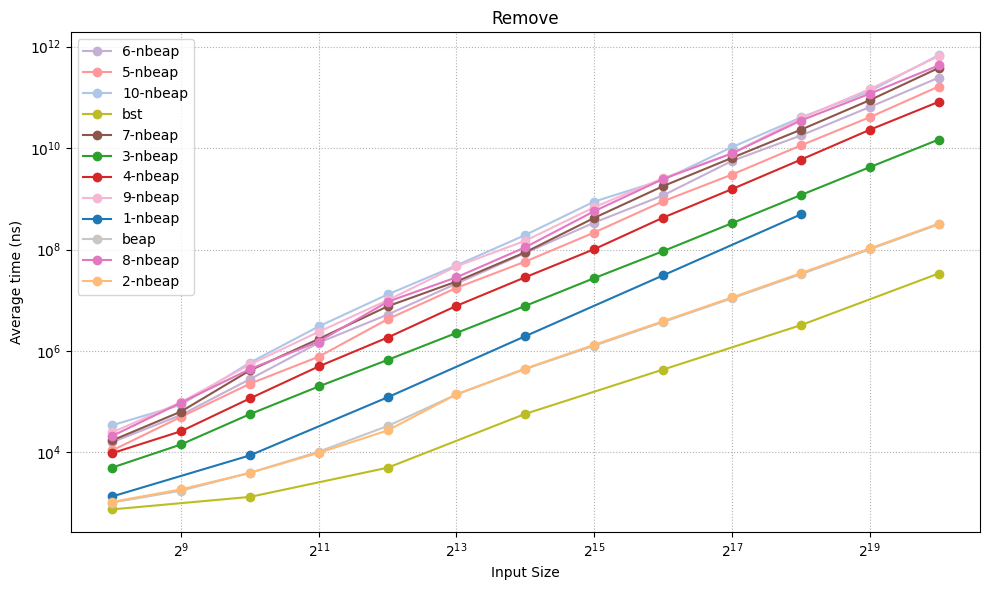

In [32]:
# Remove
plt.figure(figsize=(10, 6))
plt.title(f"Remove")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "Remove"].copy()
    if df_op.empty:
        continue
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

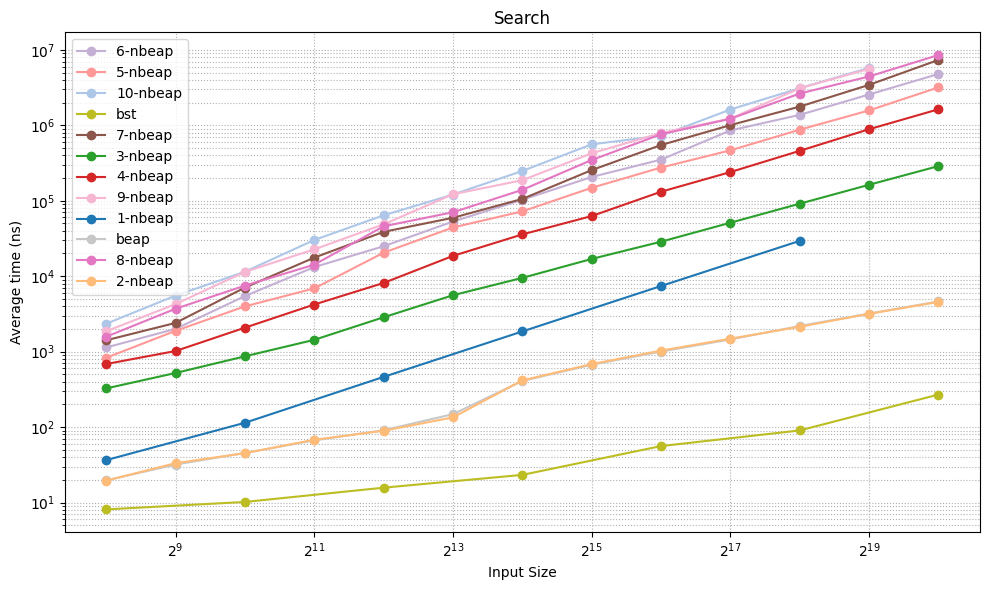

In [37]:
# Search
plt.figure(figsize=(10, 6))
plt.title(f"Search")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "Search"].copy()
    if df_op.empty:
        continue
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op["cpu_time"] = df_op["cpu_time"] / (0.05 * df_op['size'])
    df_op = df_op.sort_values("size")
    df_op = df_op[df_op["stat"] == "median"].copy()
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()